In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import helper

In [2]:
df = helper.prepare_data()

In [13]:
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values
X,y = SMOTE(random_state=42).fit_resample(X,y)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train__scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
mean_vec = np.mean(X_train, axis=0)
cov_mat = (X_train - mean_vec).T.dot((X_train - mean_vec)) / (X_train.shape[0]-1)

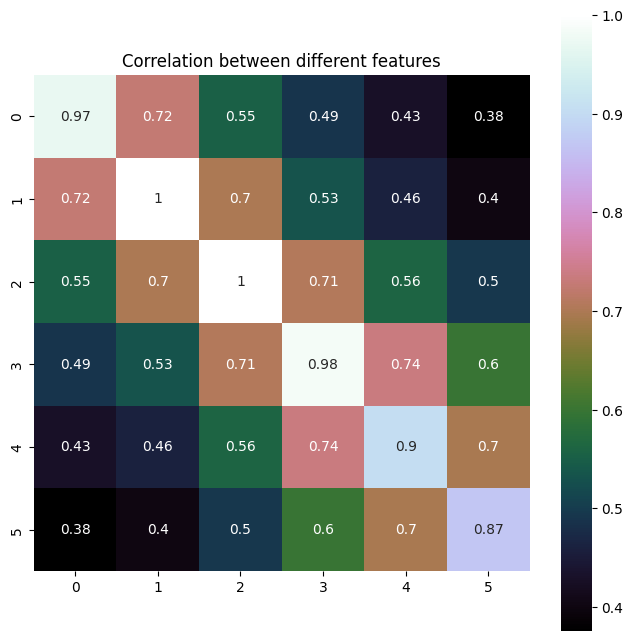

In [15]:
plt.figure(figsize=(8,8))
sns.heatmap(cov_mat, vmax=1, square=True,annot=True,cmap='cubehelix')

plt.title('Correlation between different features')
plt.show()

In [16]:
eig_vals, eig_vecs = np.linalg.eig(cov_mat)
eigen_pair = [[eig_vals[i] ,eig_vecs[:,i]] for i in range(len(eig_vals))]
eigen_pair.sort(key=lambda x : x[0], reverse=True)

In [17]:
total = sum(eig_vals)
for i, val in enumerate(eigen_pair):
  print(f"Eigen Vector {i} : {(val[0]/total)*100}%")

Eigen Vector 0 : 65.94084676791783%
Eigen Vector 1 : 15.370208803696297%
Eigen Vector 2 : 7.4007066874069105%
Eigen Vector 3 : 5.005853415206829%
Eigen Vector 4 : 3.7629510995592206%
Eigen Vector 5 : 2.519433226212895%


In [18]:
def extractComponent(n_components, eigen_pair):
  total = np.sum([pair[0] for pair in eigen_pair])
  information_retain = np.sum([eigen_pair[i][0] for i in range(n_components)])
  print(f"{(information_retain / total) * 100:.2f}% of all information will be retain")
  len_max = len(eigen_pair[0][1])
  w = np.hstack(tuple([eigen_pair[i][1].reshape(len_max,1) for i in range(n_components)]))
  return w

In [19]:
w = extractComponent(2, eigen_pair)
X_PCA_Scratch = X_train.dot(w)
X_PCA_Scratch.shape

81.31% of all information will be retain


(28886, 2)

In [20]:
sklearn_pca = PCA(n_components=2)
X_PCA_Scikit = sklearn_pca.fit_transform(X_train)
print(f"{np.sum(sklearn_pca.explained_variance_ratio_)*100:.2f}% of all information will be retained")

81.31% of all information will be retained


In [22]:
model = RandomForestClassifier(random_state=42, n_estimators=25)
model.fit(X_PCA_Scratch, y_train)

,n_estimators,25
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
X_test_pca_scratch = X_test.dot(w)
X_test_pca_skleant = sklearn_pca.transform(X_test)

Accuracy: 0.7237607310994184
Confusion Matrix:


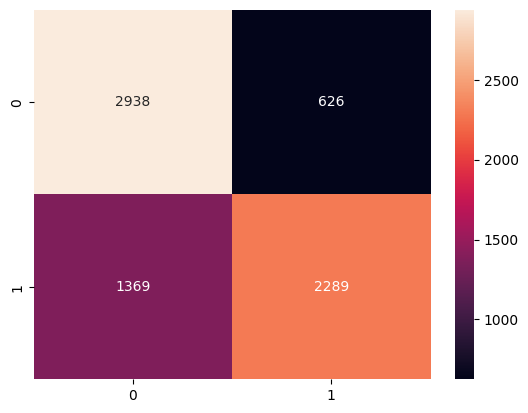

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.82      0.75      3564
           1       0.79      0.63      0.70      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.73      0.72      7222
weighted avg       0.73      0.72      0.72      7222



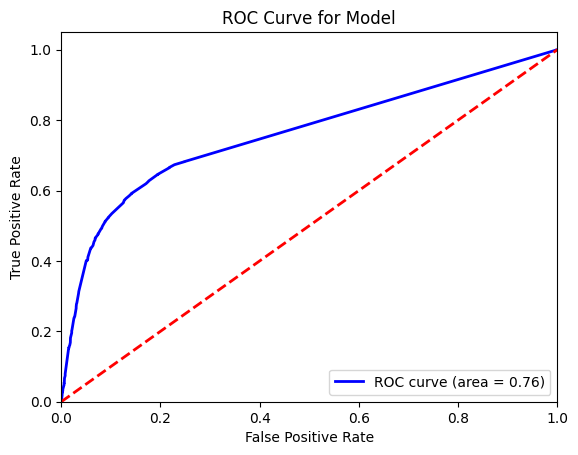

In [25]:
y_pred = model.predict(X_test_pca_scratch)
y_pred_proba = model.predict_proba(X_test_pca_scratch)[:,1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)

In [27]:
model = RandomForestClassifier(random_state=42, n_estimators=25)
model.fit(X_PCA_Scikit, y_train)

,n_estimators,25
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 0.7238991968983661
Confusion Matrix:


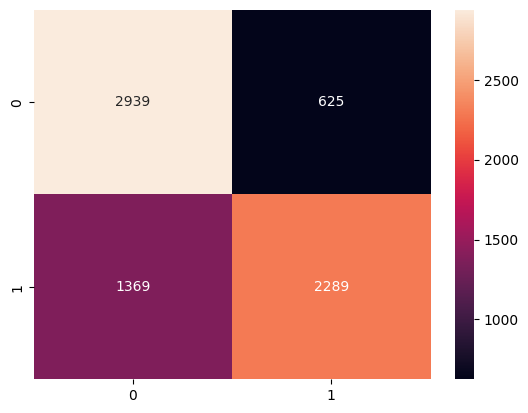

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.82      0.75      3564
           1       0.79      0.63      0.70      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.73      0.72      7222
weighted avg       0.73      0.72      0.72      7222



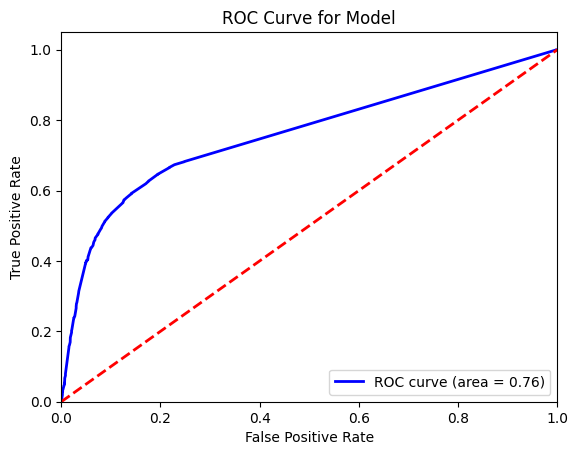

In [28]:
y_pred = model.predict(X_test_pca_skleant)
y_pred_proba = model.predict_proba(X_test_pca_skleant)[:,1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)

In [29]:
model = RandomForestClassifier(random_state=42, n_estimators=25)
model.fit(X_train, y_train)

,n_estimators,25
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 0.7245915258931044
Confusion Matrix:


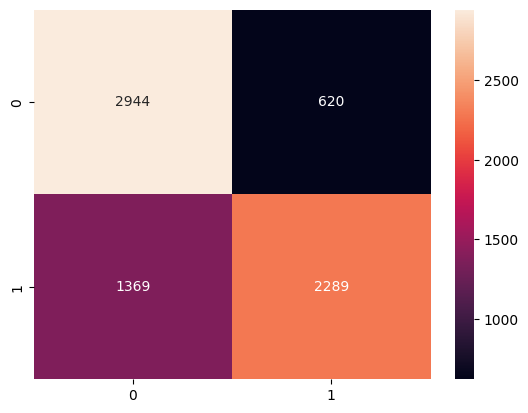

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75      3564
           1       0.79      0.63      0.70      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



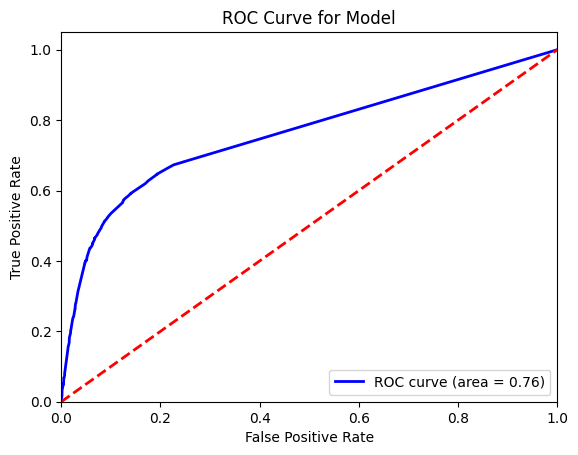

In [30]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)